# Lesson 2 — What is Optimisation?

Optimisation means finding the input `x` that makes a function `f(x)` as small as possible.

In this lesson you will:
1. Implement gradient descent from scratch
2. See how learning rate affects convergence
3. Watch gradient descent fail on hard functions
4. Understand why noisy and black-box functions break gradient methods

This failure is the reason surrogates exist.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(42)
print('Imports OK')

Imports OK


---
## Part 1 — Gradient Descent from Scratch

The gradient of a function tells you which direction is uphill. To minimise, go downhill:

$$x_{t+1} = x_t - \alpha \cdot f'(x_t)$$

where $\alpha$ is the **learning rate** (step size).

For `f(x) = x²`, the gradient is `f'(x) = 2x`. Simple.

In [2]:
def f(x):
    return x ** 2

def grad_f(x):
    return 2 * x

# Gradient descent — implemented by hand
x = 4.0       # starting point
lr = 0.1      # learning rate
history = [x]

for step in range(30):
    x = x - lr * grad_f(x)   # the update rule
    history.append(x)

history = np.array(history)
print(f'Start:  x={history[0]:.4f},  f={f(history[0]):.4f}')
print(f'End:    x={history[-1]:.6f},  f={f(history[-1]):.6f}')
print(f'True minimum: x=0,  f=0')

Start:  x=4.0000,  f=16.0000
End:    x=0.004952,  f=0.000025
True minimum: x=0,  f=0


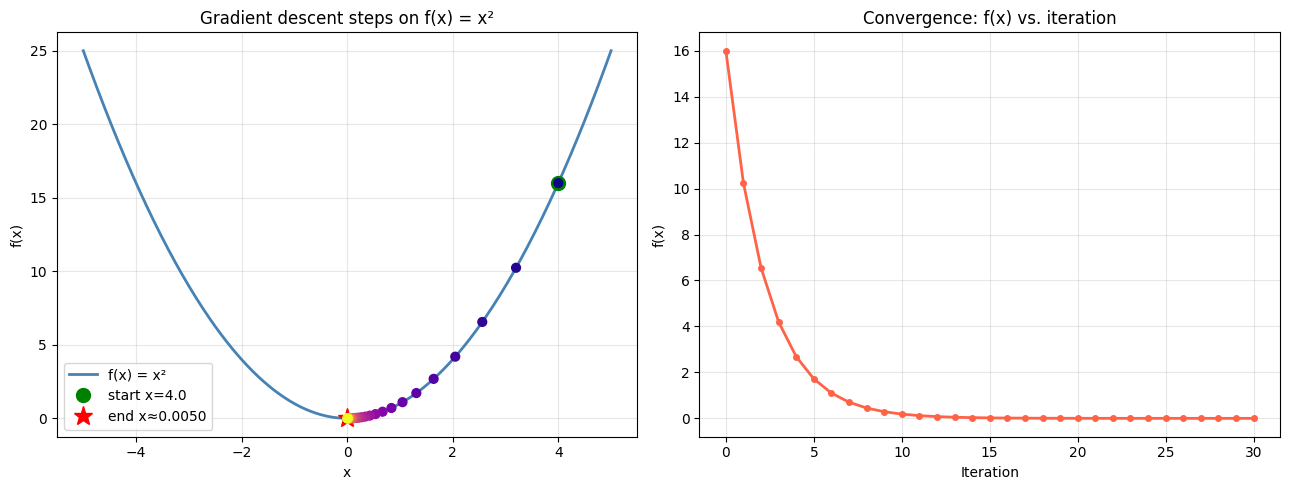

In [3]:
x_plot = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x_plot, f(x_plot), color='steelblue', linewidth=2, label='f(x) = x²')
axes[0].scatter(history, f(history), c=range(len(history)), cmap='plasma', zorder=5, s=40)
axes[0].plot(history[0], f(history[0]), 'go', markersize=10, label=f'start x={history[0]:.1f}')
axes[0].plot(history[-1], f(history[-1]), 'r*', markersize=14, label=f'end x≈{history[-1]:.4f}')
axes[0].set_title('Gradient descent steps on f(x) = x²')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(len(history)), f(history), color='tomato', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Convergence: f(x) vs. iteration')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('f(x)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Each coloured dot is one step. The colour goes from dark (early) to bright (late). Notice how steps get smaller as we approach the minimum — because the gradient `2x` gets smaller too.

**Try it:** Change `x = 4.0` to `x = -3.0`. Does it still converge?

---
## Part 2 — Effect of Learning Rate

The learning rate `α` controls how big each step is:
- **Too small** → converges, but very slowly
- **Just right** → converges quickly
- **Too large** → overshoots, diverges

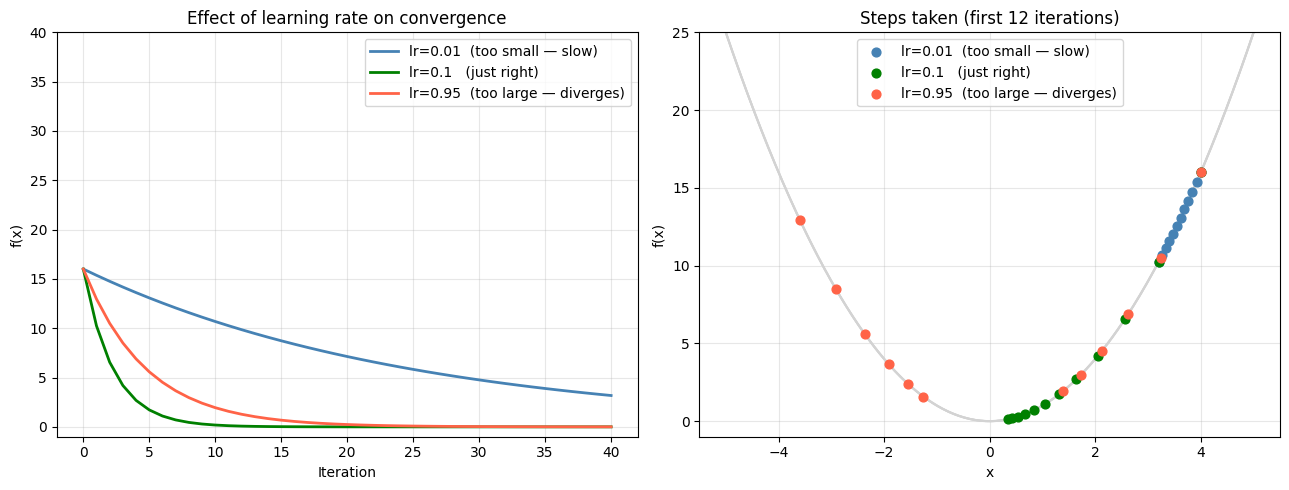

In [4]:
def run_gd(start, lr, n_steps):
    x = start
    h = [x]
    for _ in range(n_steps):
        x = x - lr * grad_f(x)
        h.append(x)
    return np.array(h)

configs = [
    (0.01, 'lr=0.01  (too small — slow)',    'steelblue'),
    (0.1,  'lr=0.1   (just right)',           'green'),
    (0.95, 'lr=0.95  (too large — diverges)', 'tomato'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for lr, label, color in configs:
    h = run_gd(start=4.0, lr=lr, n_steps=40)
    f_vals = np.clip(f(h), -5, 100)
    axes[0].plot(range(len(h)), f_vals, label=label, color=color, linewidth=2)

axes[0].set_title('Effect of learning rate on convergence')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('f(x)')
axes[0].set_ylim(-1, 40)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for lr, label, color in configs:
    h = run_gd(start=4.0, lr=lr, n_steps=40)
    axes[1].plot(x_plot, f(x_plot), color='lightgray', linewidth=1.5)
    axes[1].scatter(h[:12], np.clip(f(h[:12]), -5, 100),
                    label=label, color=color, s=40, zorder=5)

axes[1].set_title('Steps taken (first 12 iterations)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_ylim(-1, 25)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Try it:** Change `lr=0.95` to `lr=1.05`. What happens to the green line?

---
## Part 3 — SciPy on Hard Functions

Real problems are not smooth bowls. Two classic hard functions:

**Rosenbrock:** `f(x,y) = (1−x)² + 100(y−x²)²`
- Minimum at `(1, 1)` where `f=0`
- The valley is curved and very flat — hard to follow

**Ackley:** multimodal — many local minima, one global minimum at `(0,0)`
- Gradient methods often get stuck in a local minimum

In [5]:
def rosenbrock(xy):
    x, y = xy
    return (1 - x)**2 + 100 * (y - x**2)**2

def ackley(xy):
    x, y = xy
    return (-20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
            - np.exp(0.5 * (np.cos(2*np.pi*x) + np.cos(2*np.pi*y)))
            + np.e + 20)

result_rb  = minimize(rosenbrock, x0=[-1.5, 1.5], method='L-BFGS-B')
result_ack = minimize(ackley,     x0=[2.0,  2.0],  method='L-BFGS-B')

print('Rosenbrock:')
print(f'  Found:  x={result_rb.x},  f={result_rb.fun:.6f}')
print(f'  True minimum: (1, 1),  f=0')

print('\nAckley:')
print(f'  Found:  x={result_ack.x},  f={result_ack.fun:.6f}')
print(f'  True minimum: (0, 0),  f=0')

Rosenbrock:
  Found:  x=[0.99999631 0.99999262],  f=0.000000
  True minimum: (1, 1),  f=0

Ackley:
  Found:  x=[-2.87214358e-09 -2.87214358e-09],  f=0.000000
  True minimum: (0, 0),  f=0


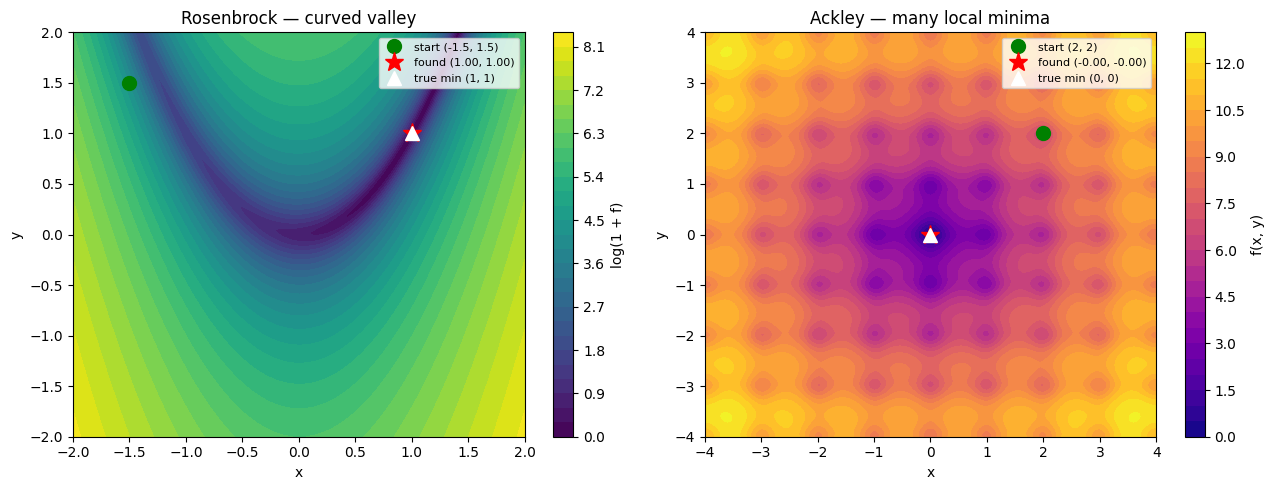

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

grid = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(grid, grid)
Z_rb = (1 - X)**2 + 100*(Y - X**2)**2

cf = axes[0].contourf(X, Y, np.log1p(Z_rb), levels=30, cmap='viridis')
fig.colorbar(cf, ax=axes[0], label='log(1 + f)')
axes[0].plot(-1.5, 1.5, 'go', markersize=10, label='start (-1.5, 1.5)')
axes[0].plot(*result_rb.x, 'r*', markersize=14,
             label=f'found ({result_rb.x[0]:.2f}, {result_rb.x[1]:.2f})')
axes[0].plot(1, 1, 'w^', markersize=10, label='true min (1, 1)')
axes[0].set_title('Rosenbrock — curved valley')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(fontsize=8)

grid_a = np.linspace(-4, 4, 200)
Xa, Ya = np.meshgrid(grid_a, grid_a)
Za = (-20*np.exp(-0.2*np.sqrt(0.5*(Xa**2+Ya**2)))
      - np.exp(0.5*(np.cos(2*np.pi*Xa)+np.cos(2*np.pi*Ya)))
      + np.e + 20)

cf2 = axes[1].contourf(Xa, Ya, Za, levels=30, cmap='plasma')
fig.colorbar(cf2, ax=axes[1], label='f(x, y)')
axes[1].plot(2, 2, 'go', markersize=10, label='start (2, 2)')
axes[1].plot(*result_ack.x, 'r*', markersize=14,
             label=f'found ({result_ack.x[0]:.2f}, {result_ack.x[1]:.2f})')
axes[1].plot(0, 0, 'w^', markersize=10, label='true min (0, 0)')
axes[1].set_title('Ackley — many local minima')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Notice the Ackley result — L-BFGS-B gets stuck in a local minimum near the start point instead of finding `(0,0)`. 

**Try it:** Change the Ackley start from `[2.0, 2.0]` to `[0.5, 0.5]`. Does it find the global minimum now?

---
## Part 4 — Gradient Descent Fails on Noisy Functions

In real problems — simulations, lab experiments, A/B tests — evaluating `f(x)` always returns `f(x) + noise`.

To estimate the gradient numerically:
$$f'(x) \approx \frac{f(x + h) - f(x - h)}{2h}$$

If each evaluation of `f` is noisy, the gradient estimate is corrupted.

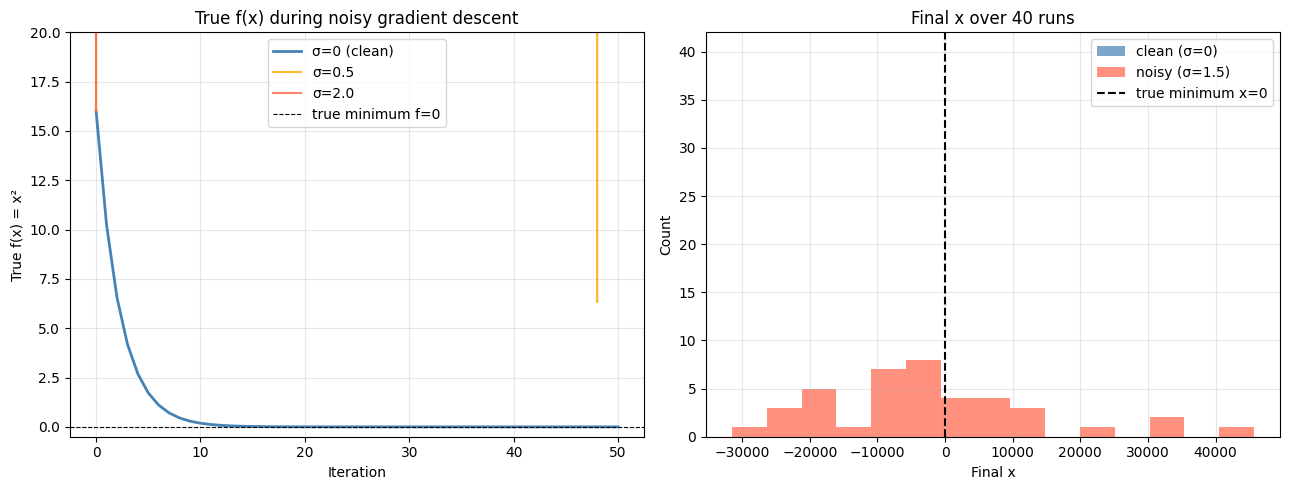

In [7]:
def f_noisy(x, sigma):
    return x**2 + np.random.normal(0, sigma)

def noisy_gradient(x, sigma, h=1e-5):
    return (f_noisy(x + h, sigma) - f_noisy(x - h, sigma)) / (2 * h)

def run_noisy_gd(start, lr, n_steps, sigma):
    x = start
    hist_x = [x]
    hist_f = [x**2]  # true value — no noise
    for _ in range(n_steps):
        g = noisy_gradient(x, sigma)
        x = x - lr * g
        hist_x.append(x)
        hist_f.append(x**2)
    return np.array(hist_x), np.array(hist_f)

clean_h = run_gd(start=4.0, lr=0.1, n_steps=50)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(len(clean_h)), f(clean_h), color='steelblue', linewidth=2, label='σ=0 (clean)')

for sigma, color, label in [(0.5, 'orange', 'σ=0.5'), (2.0, 'tomato', 'σ=2.0')]:
    _, hf = run_noisy_gd(4.0, 0.1, 50, sigma)
    axes[0].plot(range(len(hf)), hf, color=color, linewidth=1.5, alpha=0.8, label=label)

axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8, label='true minimum f=0')
axes[0].set_title('True f(x) during noisy gradient descent')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('True f(x) = x²')
axes[0].set_ylim(-0.5, 20)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution of final x across 40 independent runs
finals_clean, finals_noisy = [], []
for _ in range(40):
    h = run_gd(4.0, 0.1, 50)
    finals_clean.append(h[-1])
    hx, _ = run_noisy_gd(4.0, 0.1, 50, sigma=1.5)
    finals_noisy.append(hx[-1])

axes[1].hist(finals_clean, bins=15, alpha=0.7, color='steelblue', label='clean (σ=0)')
axes[1].hist(finals_noisy, bins=15, alpha=0.7, color='tomato', label='noisy (σ=1.5)')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5, label='true minimum x=0')
axes[1].set_title('Final x over 40 runs')
axes[1].set_xlabel('Final x')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

With clean data, every run ends very close to `x=0`. With noisy data, the final answer is scattered all over the place.

**Try it:** Change `sigma=1.5` to `sigma=0.1`. At what noise level does it start to break?

---
## Part 5 — Black-Box Functions: No Gradient at All

Many real functions have **no gradient** available:
- A simulation that returns a scalar score
- A lab experiment where you measure a physical quantity
- A neural network training run where you measure final accuracy

These are called **black-box** functions. You can evaluate them, but you cannot differentiate them.

This is where gradient descent completely fails — and where surrogates shine.

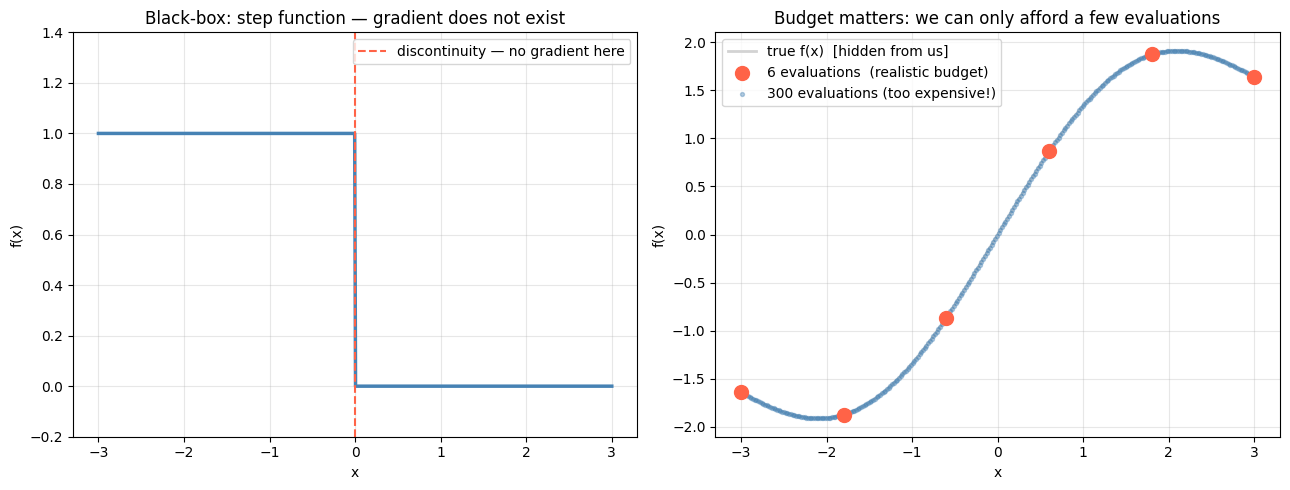

In [8]:
# A step function — no gradient at x=0, gradient=0 everywhere else
x_step = np.linspace(-3, 3, 600)
y_step = np.where(x_step < 0, 1.0, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x_step, y_step, color='steelblue', linewidth=2.5)
axes[0].axvline(0, color='tomato', linestyle='--', linewidth=1.5, label='discontinuity — no gradient here')
axes[0].set_title('Black-box: step function — gradient does not exist')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_ylim(-0.2, 1.4)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Show what "expensive" means: limited evaluation budget
x_true = np.linspace(-3, 3, 300)
f_true = np.sin(x_true) + 0.5 * x_true

x_few  = np.linspace(-3, 3, 6)
x_many = np.linspace(-3, 3, 300)

axes[1].plot(x_true, f_true, color='lightgray', linewidth=2, label='true f(x)  [hidden from us]')
axes[1].scatter(x_few, np.sin(x_few) + 0.5*x_few, color='tomato', s=100, zorder=5,
                label='6 evaluations  (realistic budget)')
axes[1].scatter(x_many, np.sin(x_many) + 0.5*x_many, color='steelblue', s=8, alpha=0.4,
                zorder=4, label='300 evaluations (too expensive!)')
axes[1].set_title('Budget matters: we can only afford a few evaluations')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

With only 6 evaluations, we can barely describe the function. We need a way to make the most of every evaluation — that is exactly what a **surrogate model** does.

---
## Summary

| Situation | Gradient descent works? | Why |
|---|---|---|
| Smooth, clean function | Yes | Gradient is accurate |
| High learning rate | No | Overshoots, diverges |
| Noisy evaluations | Struggles | Gradient estimate is corrupted |
| Black-box / discontinuous | No | No gradient to compute |
| Expensive function | Not practical | Needs too many evaluations |

**The conclusion:** for expensive, noisy, black-box functions we need a different approach — a **surrogate model** that learns from a small number of evaluations and guides the search intelligently.

---

## Exercises

1. Change the learning rate to `1.5` in Part 2. What happens? Why does `f(x)` grow instead of shrink?
2. Try gradient descent on `f(x) = abs(x)`. Implement `grad_abs` carefully — what happens at `x=0`?
3. In Part 4, increase `sigma` from `0.5` to `5.0` in small steps. At what level does gradient descent completely fail to converge?

---

## What's Next

**Lesson 3** — What is a surrogate? You will build your first surrogate model (polynomial regression) to approximate an expensive function using only a handful of evaluations.